# Plotting Learning in Restaurant Row

The goal is to plot various metrics for evaluating performance of mice in RR.

In [481]:
# Build DataFrame containing all behavior data
import jplotprefs
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import re
import matplotlib as mpl
from matplotlib import rc

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
#rc('text', usetex=False)
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
plt.rcParams.update({'font.size': 16})
plt.rcParams["figure.figsize"] = (14, 10)  # (w, h)

def calc_dwell_time(df):
    # Find index of each no-reward tone
    codes = [17,29,41,53] # no-reward tone codes
    time_stamps_tone = df.time[df.b_code.isin(codes)]
    codes = [63,66,69,72] # Exit codes & Entry codes -> in case exits wrong way
    time_stamps_exit = df.time[df.b_code.isin(codes)]
    # Calculate time to next exit
    intervals = np.zeros_like(time_stamps_tone.values)
    i=0
    for event in time_stamps_tone.values:
        diffs = time_stamps_exit-event
        interval = np.min(diffs[diffs>0])
        intervals[i] = interval/1000
        i=i+1
    no_r_dwell = np.NaN
    if ~(np.sum(intervals)==0):
        no_r_dwell = np.nanmedian(intervals)
    
    # Find index of each reward tone
    codes = [20,32,44,56] # reward tone codes
    time_stamps_tone = df.time[df.b_code.isin(codes)]
    # codes = [63,66,69,72] # Exit codes
    codes = [16,28,40,52,63,66,69,72] # Calculate time from entry to exit, back exit, or to pellet dispersal
    time_stamps_exit = df.time[df.b_code.isin(codes)]
    # Calculate time to next pellet eaten or exit
    intervals = np.zeros_like(time_stamps_tone.values)
    i=0
    for event in time_stamps_tone.values:
        diffs = time_stamps_exit-event
        interval = np.min(diffs[diffs>0])
        intervals[i] = interval/1000
        i=i+1
    r_dwell = np.NaN
    if ~(np.sum(intervals)==0):
        r_dwell = np.nanmedian(intervals)
    return [r_dwell, no_r_dwell]
    
def load_behavior(path):
    results_data = pd.DataFrame(columns=['animal_id','day',\
                                         'pellets','epoch',\
                                         'med_ipi','reward_dwell',\
                                         'no_reward_dwell',\
                                         'reject_event_count',\
                                         'reject_accuracy',\
                                         'num_laps'])
    for file in os.listdir(path):
        if file.endswith('.csv'):
            # Load csv
            data = pd.read_csv(path+file,sep=' ',header=None,names = ['time','b_code','none'])
            data = crop_time(data)
            # Pull animal ID from filename
            pattern = 'RRM.....'
            match = re.findall(pattern,file)
            animal_id = match[0]
            # Pull RR Day from filename
            pattern = 'RR_Day...'
            match = re.findall(pattern,file)
            day = float(match[0][-3:])
            # Pull epoch from filename
            pattern = 'epoch-.'
            match = re.findall(pattern,file)
            epoch = np.float(match[0][-1])
            # Count number of pellets 
            pellet_codes = [16,28,40,52] 
            num_pellets = np.sum(data.b_code.isin(pellet_codes))
            # Calculate inter-pellet interval
            time_stamps = data.time[data.b_code.isin(pellet_codes)]
            ipi = np.diff(time_stamps.values)/1000
            if len(ipi)==0:
                med_ipi = np.NaN
            else:
                med_ipi = np.median(ipi)
            # Calculate dwell time after tone
            [reward_dwell, no_reward_dwell] = calc_dwell_time(data)
            # Count number of clean reject events
            [reject_events, reject_accuracy]=collect_rejection_events(data)
            # Count number of laps
            num_laps = count_laps(data)
            # Add data to DataFrame
            results_data = results_data.append(
                {'animal_id':animal_id,'day':day,\
                'pellets':num_pellets,'epoch':epoch,\
                'med_ipi':med_ipi,'reward_dwell':reward_dwell,\
                'no_reward_dwell':no_reward_dwell,\
                'reject_event_count':len(reject_events),\
                'reject_accuracy':reject_accuracy,\
                'num_laps':num_laps},\
                ignore_index=True)
    return results_data
def plot_pellets(df):
    for animal in df.animal_id.unique():
        data = df[df.animal_id.isin([animal])]
        data = data.sort_values(by='day')
        plt.plot(data.day,data.pellets,'o-')
    plt.xlabel('Day')
    plt.ylabel('Pellets Eaten')

def plot_iti(df):

    for animal in df.animal_id.unique():
        data = df[df.animal_id.isin([animal])]
        data = data.sort_values(by='day')
        plt.plot(data.day,data.med_ipi,'o-',alpha=0.5)
    plt.xlabel('Day')
    plt.ylabel('Median Inter-Pellet Interval (s)')

def plot_dwell(df):
    plt.rcParams["figure.figsize"] = (10,6)
    
    colors = ['b','r','orange']
    ci = 0
    fig, axes = plt.subplots(1,2)
    for animal in df.animal_id.unique():
        data = df[df.animal_id.isin([animal])]
        data = data.sort_values(by='day')
        axes[ci].plot(data.day,data.reward_dwell,c='b',marker='o',alpha=0.5,markersize=16,label='reward')
        axes[ci].plot(data.day,data.no_reward_dwell,c='r',marker='v',alpha=0.5,markersize=16,label='no reward')
        axes[ci].plot()
        axes[ci].set_xlabel('Day')
        axes[ci].set_ylabel('Median Post Tone Dwell Time (s)')
        ci+=1
    plt.legend()
    plt.tight_layout()
    
def count_rejections(df):
    # This is the old version of counting rejections
    # This will find timestamps and count where all the "clean" rejections occur.
    # By this, we mean the mouse hears offer tone and completely skips the restaurant without entering it.
    no_reward_codes = [17,29,41,53] # no-reward tone codes
    reward_codes = [20,32,44,56] # reward tone codes
    exit_codes = [63,66,69,72] # Exit codes, aka "Sharp" timestamps
    entry_codes = [61,64,67,70] #Entry codes, aka "Sharp"
    accept_codes = [62,65,68,71] #Sharp accept codes
    num_no_reward_tones = len(df.index[df.b_code.isin(no_reward_codes)].values)
    tone_idx = df.index[df.b_code.isin(no_reward_codes+reward_codes)].values
    accept_idx = df.index[df.b_code.isin(accept_codes)].values
    exit_idx = df.index[df.b_code.isin(exit_codes)].values
    entry_idx = df.index[df.b_code.isin(entry_codes)].values
    num_rejects = 0
    reject_ts = []
    for event in tone_idx:
        if (np.any(entry_idx>event))&(np.any(tone_idx>event)):
            next_entry_idx = min(entry_idx[entry_idx>event])
            next_accept_idx = min(accept_idx[accept_idx>event])
            next_exit_idx = min(exit_idx[exit_idx>event])
            next_tone_idx = min(tone_idx[tone_idx>event])
            if ((next_exit_idx<next_accept_idx) & \
                (next_exit_idx<next_entry_idx)):
                num_rejects+=1
                reject_ts = np.append(reject_ts, df.time[event])
    return [num_rejects, num_no_reward_tones, reject_ts]

def collect_rejection_events(df):
    # This is the new version of counting rejections
    # This will find timestamps and count where all the "clean" rejections occur.
    # By this, we mean the mouse hears offer tone and completely skips the restaurant without entering it.
    no_reward_codes = [17,29,41,53] # no-reward tone codes
    reward_codes = [20,32,44,56] # reward tone codes
    exit_codes = [63,66,69,72] # Exit codes, aka "Sharp" timestamps
    entry_codes = [61,64,67,70] #Entry codes, aka "Sharp"
    accept_codes = [62,65,68,71] #Sharp accept codes
    reject_events = pd.DataFrame(columns=['reject_tone_ts','reject_exit_ts','restaurant'])
    num_no_offer_rejects = 0
    for rr in [1,2,3,4]:
        offer_tone_idx = df.index[df.b_code.isin([reward_codes[rr-1]])].values
        no_offer_tone_idx = df.index[df.b_code.isin([no_reward_codes[rr-1]])].values
        tone_idx = np.append(offer_tone_idx,no_offer_tone_idx)
        accept_idx = df.index[df.b_code.isin([accept_codes[rr-1]])].values
        exit_idx = df.index[df.b_code.isin([exit_codes[rr-1]])].values
        entry_idx = df.index[df.b_code.isin([entry_codes[rr-1]])].values
        for event in tone_idx:
            if (np.any(entry_idx>event)&np.any(exit_idx>event)&np.any(accept_idx>event)): #make sure entry occurs after tone
                next_entry_idx = min(entry_idx[entry_idx>event])
                next_accept_idx = min(accept_idx[accept_idx>event])
                next_exit_idx = min(exit_idx[exit_idx>event])
                #print('next entry: ' + str(next_entry_idx))
                #print('next accept: '+str(next_accept_idx))
                #print('next exit: ' + str(next_exit_idx))
                reject_ts=[]
                if next_exit_idx<next_accept_idx:
                    reject_tone_ts = df.time[event]
                    reject_exit_ts = df.time[next_exit_idx]
                    reject_events = reject_events.append({'reject_tone_ts':reject_tone_ts,'reject_exit_ts':reject_exit_ts,'restaurant':rr},ignore_index=True)
                    if event in no_offer_tone_idx:
                        num_no_offer_rejects+=1
        num_no_offers = len(df.index[df.b_code.isin(no_reward_codes)].values)
        if num_no_offers>0:        
            pct_no_offer_rejects = num_no_offer_rejects/num_no_offers
        else:
            pct_no_offer_rejects = 0
    return reject_events, pct_no_offer_rejects

def count_laps(df):
    no_reward_codes = [17,29,41,53] # no-reward tone codes
    reward_codes = [20,32,44,56] # reward tone codes
    time_stamps_tone = df.time[df.b_code.isin(no_reward_codes+reward_codes)]
    num_laps = len(time_stamps_tone)/4
    return num_laps
def plot_rejections(df):
    plt.rcParams["figure.figsize"] = (10,6) 
    colors = ['b','r','orange']
    ci = 0
    fig, axes = plt.subplots(1,2)
    for animal in df.animal_id.unique():
        data = df[df.animal_id.isin([animal])]
        data = data.sort_values(by='day')
        print('Mouse '+animal+' Rejection events per day: '+str(data.reject_event_count.values))
        axes[ci].plot(data.day,data.reject_accuracy.values,c='b',marker='o',alpha=0.5,markersize=16,label=animal)
        axes[ci].set_xlabel('Day')
        axes[ci].set_ylabel('Reject No Offer Accuracy (%)')
        axes[ci].legend()
        ci+=1
    
    plt.tight_layout()
def plot_laps(df):
    plt.rcParams["figure.figsize"] = (10,6) 
    colors = ['b','r','orange']
    ci = 0
    fig, axes = plt.subplots(1,2)
    for animal in df.animal_id.unique():
        data = df[df.animal_id.isin([animal])]
        data = data.sort_values(by='day')
        axes[ci].plot(data.day,data.num_laps.values,c='b',marker='o',alpha=0.5,markersize=16,label=animal)
        axes[ci].set_xlabel('Day')
        axes[ci].set_ylabel('Number of Laps')
        axes[ci].legend()
        ci+=1
    plt.tight_layout()
def crop_time(df):
    df_size = len(df)
    cropped_df = df[0:int(df_size)]
    return cropped_df

In [173]:
data=load_behavior('Cohort 3 D1/rr_data/')

Mouse RRM001_2 Rejection events per day: [14 5 14 16 30 74 66 36 17 46 37 53 55]
Mouse RRM002_2 Rejection events per day: [3 1 7 9 27 33 48 24 77 61 60 55]


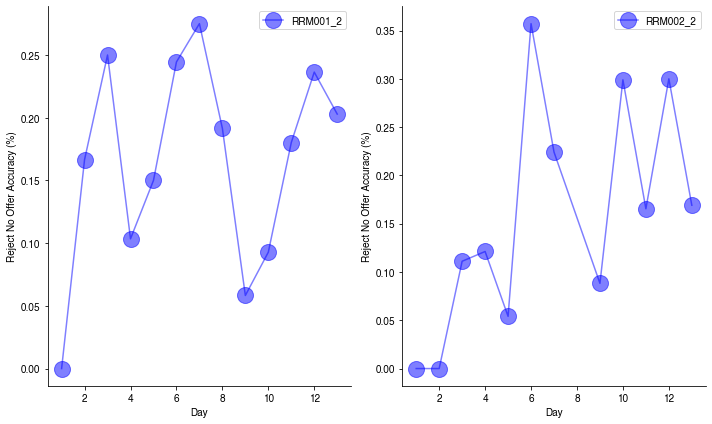

In [174]:
%matplotlib inline
plot_rejections(data)

(0.0, 120.0)

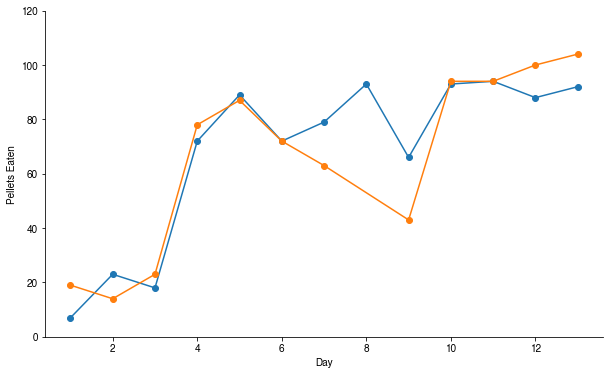

In [9]:
plot_pellets(data)
plt.ylim([0,120])

Text(0.5, 0, 'Day')

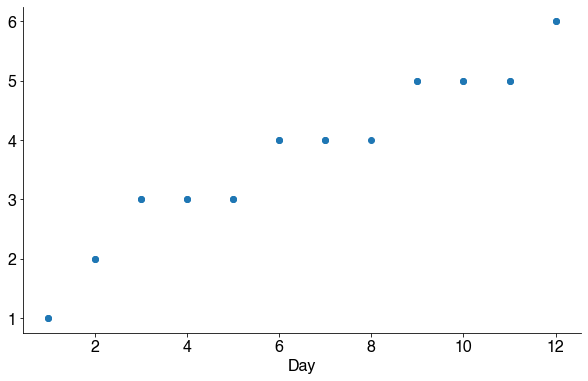

In [249]:
plt.plot(data.day,data.epoch,'o')
plt.xlabel('Day')

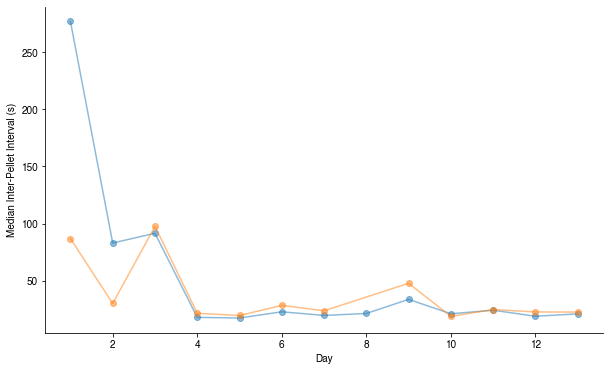

In [10]:
plot_iti(data)

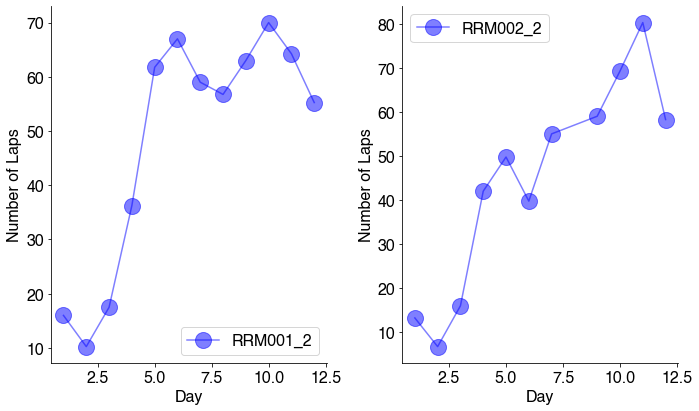

In [251]:
plot_laps(data)

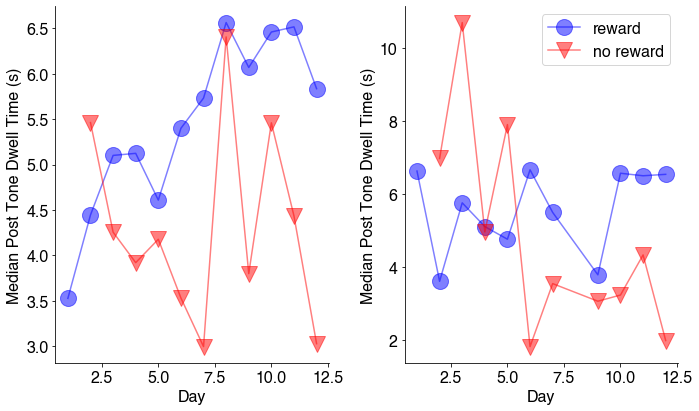

In [252]:
plot_dwell(data)

In [120]:
# Looking at single behavior file for troubleshooting
file = 'RR_Day019_epoch-4_ID-A2A18DRV_2020-11-09T15_01_41.csv'
data = pd.read_csv(file,sep=' ',header=None,names = ['time','b_code','none'])

In [121]:
data

,time,b_code,none
0,5.412395e+07,70,NaN
1,5.412395e+07,49,NaN
2,5.412395e+07,25,NaN
3,5.412396e+07,13,NaN
4,5.412397e+07,67,NaN
...,...,...,...
6747,5.738276e+07,2,NaN
6748,5.738302e+07,71,NaN
6749,5.738312e+07,47,NaN
6750,5.738385e+07,72,NaN


In [152]:
%matplotlib widget
exit_codes = [63,66,69,72] # Exit codes 
entry_codes = [61,64,67,70] # Entry codes
accept_codes = [62,65,68,71] # Accept codes
entry_codes = [61] # Entry codes
exit_codes = [63] # Exit codes
accept_codes = [62] #Sharp accept codes
time_stamps_exit = data.time[data.b_code.isin(exit_codes)]
time_stamps_entry = data.time[data.b_code.isin(entry_codes)]
time_stamps_accept = data.time[data.b_code.isin(accept_codes)]
plt.plot(time_stamps_exit/1000,np.ones_like(time_stamps_exit)*3,'o',alpha=0.5,label='exit')
plt.plot(time_stamps_entry/1000,np.ones_like(time_stamps_entry)*1,'o',alpha=0.5,label='entry')
plt.plot(time_stamps_accept/1000,np.ones_like(time_stamps_accept)*2,'o',alpha=0.5,label='accept')
plt.legend()
plt.ylim([-1,5])
plt.xlim([55401,55450])

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

(55401.0, 55450.0)

In [154]:
count_rejections(data)

[144.80639999359846, 184.34559999406338]
[329.6511999964714, 630.8735999986529]
[237.6064000055194, 617.0368000045419]
[252.23680000007153, 662.1184000074863]
[260.79999999701977, 1188.9663999974728]
[356.2111999988556, 731.4560000002384]
[232.499200001359, 641.0495999976993]
[259.0591999962926, 1213.3632000014186]
[229.67040000110865, 607.500799998641]
[529.9839999973774, 906.9695999994874]
[195.72480000555515, 642.7520000040531]
[195.0080000013113, 641.6255999952555]
[718.7839999943972, 1095.475199997425]
[229.6064000055194, 706.6495999991894]
[178.29120000451803, 588.2239999994636]
[1262.719999998808, 1638.4128000065684]
[227.5839999988675, 836.6591999977827]
[195.37919999659061, 704.332800000906]
[277.51679999381304, 719.4623999968171]
[526.0544000044465, 1725.6191999986768]
[545.3951999992132, 912.6783999949694]
[193.79200000315905, 701.8496000021696]
[361.88159999996424, 970.4959999993443]
[363.2127999961376, 840.7936000004411]
[428.5439999997616, 982.8096000030637]
[223.78239999

69

# Plotting FP Data

In [1]:
# Build DataFrame containing all behavior data
import jplotprefs
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import re
import matplotlib as mpl
from matplotlib import rc
from scipy import signal
from IPython.core.debugger import set_trace

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
#rc('text', usetex=False)
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
plt.rcParams.update({'font.size': 10})
plt.rcParams["figure.figsize"] = (8, 5)  # (w, h)

In [78]:
def get_data_directories(mouse_id, day):
    fp_folder = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/fp_data'
    behavior_folder = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/rr_data'

    for file in os.listdir(fp_folder):
        day_check = []
        mouse_id_check = []
        if file.endswith('.csv') & file.startswith('FPTS_'):
            # Pull animal ID from filename
            pattern = 'ID-[^_]+(?=_)'
            match = re.findall(pattern, file)
            if not not match:
                mouse_id_check = match[0][3:]
            # Pull RR Day from filename
            pattern = 'Dayp...'
            match = re.findall(pattern, file)
            if not not match:
                day_check = int(match[0][-3:])
            if ((not not mouse_id_check) & (not not day_check)):
                if (mouse_id == mouse_id_check) & (day == int(day_check)):
                    fpts_file = fp_folder+'/'+file
    for file in os.listdir(fp_folder):
        day_check = []
        mouse_id_check = []
        if file.endswith('.csv') & file.startswith('FP_'):
            # Pull animal ID from filename
            pattern = 'ID-[^_]+(?=_)'
            match = re.findall(pattern, file)
            if not not match:
                mouse_id_check = match[0][3:]
            # Pull RR Day from filename
            pattern = 'Dayp...'
            match = re.findall(pattern, file)
            if not not match:
                day_check = int(match[0][-3:])
            if ((not not mouse_id_check) & (not not day_check)):
                if (mouse_id == mouse_id_check) & (day == int(day_check)):
                    fp_file = fp_folder+'/'+file
    for file in os.listdir(behavior_folder):
        day_check = []
        mouse_id_check = []
        if file.endswith('.csv') & file.startswith('RR_'):
            # Pull animal ID from filename
            pattern = 'ID-[^_]+(?=_)'
            match = re.findall(pattern, file)
            if not not match:
                mouse_id_check = match[0][3:]
            # Pull RR Day from filename
            pattern = 'Dayp...'
            match = re.findall(pattern, file)
            if not not match:
                day_check = int(match[0][-3:])
            if ((not not mouse_id_check) & (not not day_check)):
                if (mouse_id == mouse_id_check) & (day == int(day_check)):
                    rr_file = behavior_folder + '/' + file
    print(fp_file)
    return rr_file, fp_file, fpts_file


def get_fp_plots(animal, day, alignment, sg, side, condition, split=False, plot_flag='mean'):
    #animal = 'A2A18DRV'
    #day = 282
    (rr_file, fp_file, fp_time_stamps) = get_data_directories(animal, day)

    #fp_file = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 2 A2A/fp_data/FP_Dayp278_epoch-7_ID-A2A18DRV_2021-01-07T10_40_53.csv'
    #fp_time_stamps = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 2 A2A/fp_data/FPTS_Dayp278_epoch-7_ID-A2A18DRV_2021-01-07T10_40_08.csv'
    #rr_file = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 2 A2A/rr_data/RR_Dayp278_epoch-7_ID-A2A18DRV2021-01-07T10_40_08.csv'

    data = pd.read_csv(fp_file, skiprows=1, names=[
                       'frame', 'cam_time_stamp', 'flag', 'right_red', 'left_red', 'right_green', 'left_green'])
    data_time_stamps = pd.read_csv(
        fp_time_stamps, names=['time_stamps'])

    data_fp = pd.concat([data, data_time_stamps.time_stamps], axis=1)
    rr_data = pd.read_csv(rr_file, sep=' ', header=None,
                          names=['time', 'b_code', 'none'])

    # Classify events and add class to data_rr df
    (reject_events,
     accept_and_rewarded_events,
     num_accept_rewarded_events,
     quit_events, num_quit_events,
     pct_no_offer_rejects,
     data_rr) = classify_events(rr_data)
    '''
    # Green signal
    right_green_fp = data_fp.right_green[data_fp.flag == 2].values
    right_green_fp_ts = data_fp.time_stamps[data_fp.flag == 2].values
    left_green_fp = data_fp.left_green[data_fp.flag == 2].values
    left_green_fp_ts = data_fp.time_stamps[data_fp.flag == 2].values
    # Red signal
    right_red_fp = data_fp.right_red[data_fp.flag == 4].values
    right_red_fp_ts = data_fp.time_stamps[data_fp.flag == 4].values
    left_red_fp = data_fp.left_red[data_fp.flag == 4].values
    left_red_fp_ts = data_fp.time_stamps[data_fp.flag == 4].values
    # Control signal (415nm)
    right_control_fp = data_fp.right_green[data_fp.flag == 1].values
    right_control_fp_ts = data_fp.time_stamps[data_fp.flag == 1].values
    left_control_fp = data_fp.left_green[data_fp.flag == 1].values
    left_control_fp_ts = data_fp.time_stamps[data_fp.flag == 1].values
    '''

    # condition can be "reject","rewarded" or "quit"
    plot_trace_probs(alignment, sg, side, condition, data_fp,
                     data_rr, split, plot_flag)


def plot_trace_probs(alignment, sg, side, condition, data_fp, data_rr, split, plot_flag):
    events = {
        'reward': [16, 28, 40, 52],
        # Servo arm open (should track with pellet taken fro dispenser)
        'servo_open': [1, 3, 5, 7],
        'reward_omission': [15, 27, 39, 51],
        'offer_tone_0': [17, 29, 41, 53],  # no-reward tone codes
        'offer_tone_20': [18, 30, 42, 54],
        'offer_tone_80': [19, 31, 43, 55],  # 80pct rewarded tone codes
        'offer_tone_100': [20, 32, 44, 56],  # reward tone codes
        # DOESNT WORK BECAUSE CYCLING THROUGH ONLY 4 codes of diff restaurants
        'any_offer': [17, 18, 19, 20, 29, 30, 31, 32, 41, 42, 43, 44, 53, 54, 55, 56],
        'exit': [63, 66, 69, 72],
        'entry': [61, 64, 67, 70],
        'accept': [62, 65, 68, 71]
    }
    if alignment == 'reject':
        [num_rejects, num_no_reward_tones,
            reject_ts] = count_rejections(data_rr)
        event_ts = reject_ts
    else:
        event_codes = events.get(alignment)

    if side == 'left':
        if sg == 'green':
            signal_fp = data_fp.left_green[data_fp.flag == 2].values
            # Baseline and z-score FP trace
            signal_fp = baseline_trace(signal_fp)
            signal_fp_ts = data_fp.time_stamps[data_fp.flag == 2].values
            signal_fp_ts = signal_fp_ts[~np.isnan(
                signal_fp_ts)]  # remove trailing nan
        elif sg == 'red':
            signal_fp = data_fp.left_red[data_fp.flag == 4].values
            signal_fp = baseline_trace(signal_fp)
            signal_fp_ts = data_fp.time_stamps[data_fp.flag == 4].values
            signal_fp_ts = signal_fp_ts[~np.isnan(
                signal_fp_ts)]  # remove trailing nan
        elif sg == 'control':
            signal_fp = data_fp.left_green[data_fp.flag == 1].values
            signal_fp = baseline_trace(signal_fp)
            signal_fp_ts = data_fp.time_stamps[data_fp.flag == 1].values
            signal_fp_ts = signal_fp_ts[~np.isnan(
                signal_fp_ts)]  # remove trailing nan
    if side == 'right':
        if sg == 'green':
            signal_fp = data_fp.right_green[data_fp.flag == 2].values
            signal_fp = baseline_trace(signal_fp)
            signal_fp_ts = data_fp.time_stamps[data_fp.flag == 2].values
            signal_fp_ts = signal_fp_ts[~np.isnan(
                signal_fp_ts)]  # remove trailing nan
        elif sg == 'red':
            signal_fp = data_fp.right_red[data_fp.flag == 4].values
            signal_fp = baseline_trace(signal_fp)
            signal_fp_ts = data_fp.time_stamps[data_fp.flag == 4].values
            signal_fp_ts = signal_fp_ts[~np.isnan(
                signal_fp_ts)]  # remove trailing nan
        elif sg == 'control':
            signal_fp = data_fp.right_green[data_fp.flag == 1].values
            signal_fp = baseline_trace(signal_fp)
            signal_fp_ts = data_fp.time_stamps[data_fp.flag == 1].values
            signal_fp_ts = signal_fp_ts[~np.isnan(
                signal_fp_ts)]  # remove trailing nan

    # Calculate time window for plotting FP data
    WINDOW_S = 3  # number of seconds before and after event to plot FP data
    frame_interval = np.nanmean(np.diff(signal_fp_ts))/1000
    # Time window in units of "frames"
    time_window = int(WINDOW_S/frame_interval)
    if split == True:
        fig, axes = plt.subplots(2, 2)
        ax_index = [(0, 0), (0, 1), (1, 0), (1, 1)]
        for rr in [1, 2, 3, 4]:
            if alignment != 'reject':
                event_code = event_codes[rr-1]
                event_idx = data_rr.b_code[data_rr.b_code ==
                                           event_code].index.tolist()
                condition_matched = np.array([])
                # Filter for events that match condition: 'reject', 'rewarded', 'quit'
                if np.sum(event_idx) > 0:
                    for event in event_idx:
                        if (data_rr.event_class[event] == condition):
                            condition_matched = np.append(
                                condition_matched, event)
                event_idx = condition_matched
                event_ts = data_rr.time[event_idx].values

            for prob in [0, 20, 80, 100]:
                if len(event_ts) < 1:
                    print(
                        f"Restaurant {rr} has no traces for probability tone {prob}")
                    continue
                #traces = np.zeros([len(event_ts), time_window*2])
                #traces = np.zeros([0, time_window*2])
                if prob == 0:
                    traces = np.zeros([0, time_window*2])
                elif plot_flag!='heatmap':
                    traces = np.zeros([0, time_window*2])
                for i in np.arange(0, len(event_ts), 1):
                    if data_rr.offer_tone[event_idx[i]] == prob:
                        # Time value of event from computer clock
                        ts_rr = event_ts[i]
                        # Index of timestamp that coincides with event timestamp
                        ts_fp = np.argmax(signal_fp_ts > ts_rr)
                        # print('---')
                        #print('Event timestamp: '+str(ts_rr))
                        #print('FP aligned timestamp: '+ str(signal_fp_ts[ts_fp]))
                        #print('Difference: '+str(signal_fp_ts[ts_fp]-ts_rr))
                        if (ts_fp > time_window) & ((ts_fp+time_window) < len(signal_fp)):
                            #trace = signal_fp[ts_fp-time_window:ts_fp+time_window]
                            #traces = np.vstack([traces, trace-trace[0]])
                            trace = signal_fp[ts_fp -
                                              time_window:ts_fp+time_window]
                            traces = np.vstack([traces, trace])
                t = np.arange(-time_window, time_window, 1)*frame_interval
                if np.shape(traces)[0] < 1:
                    # Create zero trace if no events occur
                    traces = np.zeros([1, time_window*2])
                mean_trace = np.mean(traces, axis=0)
                sem_trace = np.std(traces, axis=0)/np.sqrt(len(traces))
                extent = [min(t), max(t), 0, 1]
                if plot_flag == 'heatmap':
                    axes[ax_index[rr-1]].imshow(traces, extent=extent)
                # axes[ax_index[rr-1]].plot(traces.T)
                if plot_flag == 'mean':
                    axes[ax_index[rr-1]].plot(t, mean_trace,
                                              label=str(prob)+'% tone')
                    axes[ax_index[rr-1]].fill_between(t, mean_trace+sem_trace,
                                                      mean_trace-sem_trace, alpha=0.5)
                    axes[ax_index[rr-1]].set_xlabel('Time (s)')
                    axes[ax_index[rr-1]].set_ylabel('FL Signal (a.u)')
                    #axes[ax_index[rr-1]].title(alignment + ' ' + sg + ', R'+str(rr))
                    axes[ax_index[rr-1]].set_title('R'+str(rr))
                    axes[ax_index[rr-1]].legend()
                    # axes[ax_index[rr-1]].set_ylim([-.00004,.00005])
                    # axes[ax_index[rr-1]].set_ylim(ymin,ymax)
            ymin, ymax = axes[ax_index[rr-1]].get_ylim()
            axes[ax_index[rr-1]].plot([0, 0], [ymin, ymax], '--k')

    else:
        fig, axes = plt.subplots()
        if alignment != 'reject':
            event_idx = np.empty([0,1])
            for code in np.arange(len(event_codes)):
                event_code = event_codes[code]
                event_idx = np.append(event_idx, data_rr.b_code[data_rr.b_code ==
                                                                event_code].index.tolist())
            condition_matched = np.array([])
            # Filter for events that match condition: 'reject', 'rewarded', 'quit'
            if np.sum(event_idx) > 0:
                for event in event_idx:
                    if (data_rr.event_class[event] == condition):
                        condition_matched = np.append(condition_matched, event)
            event_idx = condition_matched
            event_ts = data_rr.time[event_idx].values
        c = 0
        for prob in [0, 20, 80, 100]:
            if len(event_ts) < 1:
                print(
                    f"Restaurant {rr} has no traces for probability tone {prob}")
                continue
            #traces = np.zeros([len(event_ts), time_window*2])
            if prob == 0:
                traces = np.zeros([0, time_window*2])
            elif plot_flag!='heatmap':
                traces = np.zeros([0, time_window*2])
            for i in np.arange(0, len(event_ts), 1):
                if data_rr.offer_tone[event_idx[i]] == prob:
                    # Time value of event from computer clock
                    ts_rr = event_ts[i]
                    # Index of timestamp that coincides with event timestamp
                    ts_fp = np.argmax(signal_fp_ts > ts_rr)
                    # print('---')
                    #print('Event timestamp: '+str(ts_rr))
                    #print('FP aligned timestamp: '+ str(signal_fp_ts[ts_fp]))
                    #print('Difference: '+str(signal_fp_ts[ts_fp]-ts_rr))
                    if (ts_fp > time_window) & ((ts_fp+time_window) < len(signal_fp)):
                        #trace = signal_fp[ts_fp-time_window:ts_fp+time_window]
                        #traces = np.vstack([traces, trace-trace[0]])
                        trace = signal_fp[ts_fp-time_window:ts_fp+time_window]
                        traces = np.vstack([traces, trace])
            t = np.arange(-time_window, time_window, 1)*frame_interval
            if np.shape(traces)[0] < 1:
                # Create zero trace if no events occur
                traces = np.zeros([1, time_window*2])
            mean_trace = np.mean(traces, axis=0)
            sem_trace = np.std(traces, axis=0)/np.sqrt(len(traces))
            extent = [min(t), max(t), 0, 1]
            if plot_flag == 'heatmap':
                axes.imshow(traces, extent=extent)
            color_idx = ['k','r','g','b']
            if plot_flag == 'all':
                axes.plot(t, traces.T,color_idx[c],alpha=0.5)
                c+=1
                print(c)
            if plot_flag == 'mean':
                axes.plot(t, mean_trace,
                          label=str(prob)+'% tone')
                axes.fill_between(t, mean_trace+sem_trace,
                                  mean_trace-sem_trace, alpha=0.5)
                axes.set_xlabel('Time (s)')
                axes.set_ylabel('FL Signal (a.u)')
                #axes[ax_index[rr-1]].title(alignment + ' ' + sg + ', R'+str(rr))
                #axes.set_title('R'+str(rr))
                axes.legend()
                # axes[ax_index[rr-1]].set_ylim([-.00004,.00005])
                # axes[ax_index[rr-1]].set_ylim(ymin,ymax)
        ymin, ymax = axes.get_ylim()
        axes.plot([0, 0], [ymin, ymax], '--k')

        fig_title = alignment+' '+side+' '+sg+' '+condition
        plt.suptitle(fig_title)
        plt.tight_layout()


def classify_events(df):
    # This will find timestamps and count where all the "clean" rejections occur.
    # By this, we mean the mouse hears offer tone and completely skips the restaurant without entering it.
    data_rr = df.assign(event_class=np.ones(len(df)) *
                        np.nan)  # Add 'event_class' column
    # Add 'offer_tone' column to indicate which tone was given for each event
    data_rr = df.assign(offer_tone=np.ones(len(df)) * np.nan)
    reward_codes_0 = [17, 29, 41, 53]  # no-reward tone codes
    reward_codes_20 = [18, 30, 42, 54]  # 20pct rewarded tone codesc
    reward_codes_80 = [19, 31, 43, 55]  # 80pct rewarded tone codes
    reward_codes_100 = [20, 32, 44, 56]  # reward tone codes
    reward_taken_codes = [16, 28, 40, 52]  # Pellet taken from dispenser
    # Servo arm open (should track with pellet taken fro dispenser)
    servo_open_codes = [1, 3, 5, 7]
    exit_codes = [63, 66, 69, 72]  # Exit codes, aka "Sharp" timestamps
    entry_codes = [61, 64, 67, 70]  # Entry codes, aka "Sharp"
    accept_codes = [62, 65, 68, 71]  # Sharp accept codes
    # Data frame initialization for holding sorted event timestamps
    reject_events = pd.DataFrame(
        columns=['reject_tone_ts', 'reject_exit_ts', 'restaurant'])
    num_no_offer_rejects = 0
    accept_and_rewarded_events = pd.DataFrame(
        columns=['tone_ts', 'accept_ts', 'restaurant'])
    num_accept_rewarded_events = 0
    accept_not_rewarded_events = pd.DataFrame(
        columns=['tone_ts', 'accept_ts', 'restaurant'])
    num_accept_not_rewarded_events = 0
    quit_events = pd.DataFrame(columns=['tone_ts', 'quit_ts', 'restaurant'])
    num_quit_events = 0

    for rr in [1, 2, 3, 4]:
        offer_tone_100_idx = df.index[df.b_code.isin(
            [reward_codes_100[rr-1]])].values
        offer_tone_80_idx = df.index[df.b_code.isin(
            [reward_codes_80[rr-1]])].values
        offer_tone_20_idx = df.index[df.b_code.isin(
            [reward_codes_20[rr-1]])].values
        offer_tone_0_idx = df.index[df.b_code.isin(
            [reward_codes_0[rr-1]])].values
        num_no_offers = len(offer_tone_0_idx)
        tone_idx = np.append(offer_tone_100_idx, offer_tone_80_idx)
        tone_idx = np.append(tone_idx, offer_tone_20_idx)
        tone_idx = np.append(tone_idx, offer_tone_0_idx)
        accept_idx = df.index[df.b_code.isin([accept_codes[rr-1]])].values
        exit_idx = df.index[df.b_code.isin([exit_codes[rr-1]])].values
        entry_idx = df.index[df.b_code.isin([entry_codes[rr-1]])].values
        reward_taken_idx = df.index[df.b_code.isin(
            [reward_taken_codes[rr-1]])].values  # Pellet taken from dispenser
        # Servo arm open (should track with pellet taken fro dispenser)
        servo_open_idx = df.index[df.b_code.isin(
            [servo_open_codes[rr-1]])].values
        print('Pellets Revealed R' + str(rr)+': '+str(len(servo_open_idx)))
        print('Pellets Eaten R' + str(rr)+': '+str(len(reward_taken_idx)))
        for event in tone_idx:
            # Determine which offer tone was given for each event
            code = df.b_code[event]
            if code in reward_codes_0:
                tone_prob = 0
            if code in reward_codes_20:
                tone_prob = 20
            if code in reward_codes_80:
                tone_prob = 80
            if code in reward_codes_100:
                tone_prob = 100
            # make sure events occurs after tone (e.g. not last unfinished trial)
            if (np.any(entry_idx > event) & np.any(exit_idx > event) & np.any(servo_open_idx > event)):
                next_entry_idx = min(entry_idx[entry_idx > event])
                next_accept_idx = min(accept_idx[accept_idx > event])
                next_exit_idx = min(exit_idx[exit_idx > event])
                next_pellet_reveal_idx = min(
                    servo_open_idx[servo_open_idx > event])
                # print('Tone: '+ str(event))
                # print('Entry: '+str(next_entry_idx))
                # print('Accept: '+str(next_accept_idx))
                # print('Pellet taken: '+str(next_pellet_reveal_idx))
                # print('Exit: '+str(next_exit_idx))
                # Reject Events
                if next_exit_idx < next_accept_idx:
                    # print('Reject')
                    reject_tone_ts = df.time[event]
                    reject_exit_ts = df.time[next_exit_idx]
                    reject_events = reject_events.append(
                        {'reject_tone_ts': reject_tone_ts, 'reject_exit_ts': reject_exit_ts, 'restaurant': rr}, ignore_index=True)
                    if event in offer_tone_0_idx:
                        num_no_offer_rejects += 1
                    data_rr.loc[event, 'event_class'] = 'reject'
                    data_rr.loc[next_entry_idx, 'event_class'] = 'reject'
                    data_rr.loc[next_accept_idx, 'event_class'] = np.nan
                    data_rr.loc[next_exit_idx, 'event_class'] = 'reject'
                    data_rr.loc[event, 'offer_tone'] = tone_prob
                    data_rr.loc[next_entry_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_accept_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_exit_idx, 'offer_tone'] = tone_prob

                # Accept_rewarded events
                if (next_pellet_reveal_idx < next_exit_idx):
                    # print('Accept')
                    accept_tone_ts = df.time[event]
                    accept_event_ts = df.time[next_accept_idx]
                    accept_and_rewarded_events = accept_and_rewarded_events.append(
                        {'tone_ts': accept_tone_ts, 'accept_ts': accept_event_ts, 'restaurant': rr}, ignore_index=True)
                    num_accept_rewarded_events += 1
                    data_rr.loc[event, 'event_class'] = 'rewarded'
                    data_rr.loc[next_entry_idx, 'event_class'] = 'rewarded'
                    data_rr.loc[next_accept_idx, 'event_class'] = 'rewarded'
                    data_rr.loc[next_exit_idx, 'event_class'] = 'rewarded'
                    data_rr.loc[next_pellet_reveal_idx,
                                'event_class'] = 'rewarded'
                    data_rr.loc[event, 'offer_tone'] = tone_prob
                    data_rr.loc[next_entry_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_accept_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_exit_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_pellet_reveal_idx,
                                'offer_tone'] = tone_prob
                # Accept_not_rewareded events

                # Quit events
                if (next_exit_idx > next_accept_idx) & (next_pellet_reveal_idx > next_exit_idx):
                    # print('Quit')
                    quit_tone_ts = df.time[event]
                    quit_event_ts = df.time[next_exit_idx]
                    quit_events = quit_events.append(
                        {'tone_ts': quit_tone_ts, 'quit_ts': quit_event_ts, 'restaurant': rr}, ignore_index=True)
                    num_quit_events += 1
                    data_rr.loc[event, 'event_class'] = 'quit'
                    # print(data_rr.event_class[event])
                    data_rr.loc[next_entry_idx, 'event_class'] = 'quit'
                    data_rr.loc[next_accept_idx, 'event_class'] = 'quit'
                    data_rr.loc[next_exit_idx, 'event_class'] = 'quit'
                    data_rr.loc[event, 'offer_tone'] = tone_prob
                    data_rr.loc[next_entry_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_accept_idx, 'offer_tone'] = tone_prob
                    data_rr.loc[next_exit_idx, 'offer_tone'] = tone_prob

            # input('Calculate next event...')
        #pct_no_offer_rejects = num_no_offer_rejects/num_no_offers
        pct_no_offer_rejects = 0  # Replaced to avoid div by 0 error when there are few events
    return (reject_events,
            accept_and_rewarded_events,
            num_accept_rewarded_events,
            quit_events,
            num_quit_events,
            pct_no_offer_rejects,
            data_rr)


def baseline_trace(trace):
    frame_interval = 0.025
    med_filt = signal.medfilt(
        trace, 1+int(3/frame_interval))  # 3 second long kernel
    trace_backsub = trace-med_filt
    std_trace = np.zeros_like(trace)
    # for i in np.arange(0, len(trace)-int(3/frame_interval)):
    #    std_trace[i] = np.std(trace_backsub[i:i+int(3/frame_interval)])
    # fill zero end pads
    #std_trace[std_trace == 0] = np.mean(std_trace)
    #zscore_trace = trace_backsub/std_trace
    zscore_trace = trace_backsub/(np.std(med_filt))
    return zscore_trace

In [95]:
%matplotlib widget
get_fp_plots('RRM001',132,'accept','green', 'right', 'rewarded',False,'heatmap')
get_fp_plots('RRM001',132,'accept','green', 'left', 'rewarded',False,'heatmap')
plt.savefig('plot.jpg')

/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/fp_data/FP_Dayp132_epoch-8_ID-RRM001_2021-01-27T15_42_12.csv
Pellets Revealed R1: 5
Pellets Eaten R1: 8
Pellets Revealed R2: 9
Pellets Eaten R2: 9
Pellets Revealed R3: 8
Pellets Eaten R3: 8
Pellets Revealed R4: 9
Pellets Eaten R4: 9


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/fp_data/FP_Dayp132_epoch-8_ID-RRM001_2021-01-27T15_42_12.csv
Pellets Revealed R1: 5
Pellets Eaten R1: 8
Pellets Revealed R2: 9
Pellets Eaten R2: 9
Pellets Revealed R3: 8
Pellets Eaten R3: 8
Pellets Revealed R4: 9
Pellets Eaten R4: 9


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [89]:
get_fp_plots('RRM001',132,'offer_tone_100','green', 'left', 'rewarded',False,'heatmap')
plt.savefig('plot.jpg')

/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/fp_data/FP_Dayp132_epoch-8_ID-RRM001_2021-01-27T15_42_12.csv
Pellets Revealed R1: 5
Pellets Eaten R1: 8
Pellets Revealed R2: 9
Pellets Eaten R2: 9
Pellets Revealed R3: 8
Pellets Eaten R3: 8
Pellets Revealed R4: 9
Pellets Eaten R4: 9


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [81]:
# Testing

#Load df
fp_file = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/fp_data/FP_Dayp130_epoch-8_ID-RRM002_2021-01-25T16_24_26.csv'
data = pd.read_csv(fp_file, skiprows=1, names=[
                       'frame', 'cam_time_stamp', 'flag', 'right_red', 'left_red', 'right_green', 'left_green'])
fp_trace = data['right_red']
fp_trace = fp_trace[data.flag == 4].values

results = baseline_trace(fp_trace)

plt.plot(results)

# Plotting behavior events for debugging

In [357]:
data_rr = pd.read_csv(rr_file,sep=' ',header=None,names = ['time','b_code','none'])

def plot_events():
    events = {
        'reward': [16, 28, 40, 52],
        'servo_open': [1,3,5,7],
        #'reward_omission': [15, 27, 39, 51],
        #'no_offer_tone': [17, 29, 41, 53],
        'offer_tone': [17,18,19,20,29,30,31,32,41,42,43,44,53,54,55,56],
        #'offer_tone_0': [17, 29, 41, 53],  # no-reward tone codes
        #'offer_tone_20': [18, 30, 42, 54],
        #'offer_tone_80': [19, 31, 43, 55],  # 80pct rewarded tone codes
        #'offer_tone_100': [20, 32, 44, 56],  # reward tone codes
        #'exit': [63, 66, 69, 72],
        #'entry': [61, 64, 67, 70],
        #'accept': [62, 65, 68, 71],
        #'quit': [13,25,37,49],
    }

    offset=0    
    for event in events.keys():
        #for rr in [1,2,3,4]:
        event_codes = events[event]
        #event_code = event_codes[rr-1]
        event_code = event_codes
        event_idx = data_rr.b_code.isin(event_code)
        event_ts = data_rr.time[event_idx].values
        plt.plot((event_ts-np.nanmin(data_rr.time.values))/1000,np.ones_like(event_ts)+offset,'o',label=event)
        offset+=1
    
    plt.tight_layout()
    plt.legend()
    plt.ylim([0,8])

In [358]:
%matplotlib widget
plot_events()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

In [263]:
reject_events.reject_tone_ts

0     5.953824e+07
1     6.041131e+07
2     6.057399e+07
3     6.084337e+07
4     6.060176e+07
5     6.064691e+07
6     6.076148e+07
7     6.085181e+07
8     6.013506e+07
9     6.041191e+07
10    6.057468e+07
11    6.060221e+07
12    6.084398e+07
13    6.064819e+07
14    6.076212e+07
Name: reject_tone_ts, dtype: float64

In [419]:
# Plot green and red traces for troubleshooting
%matplotlib widget
fig, ax = plt.subplots()
ax.plot((green_fp_ts-np.nanmin(green_fp_ts))/1000,green_fp,'g')
ax.plot((red_fp_ts-np.nanmin(red_fp_ts))/1000,red_fp,'r')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Raw FL Signal (a.u.)')


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Text(0, 0.5, 'Raw FL Signal (a.u.)')

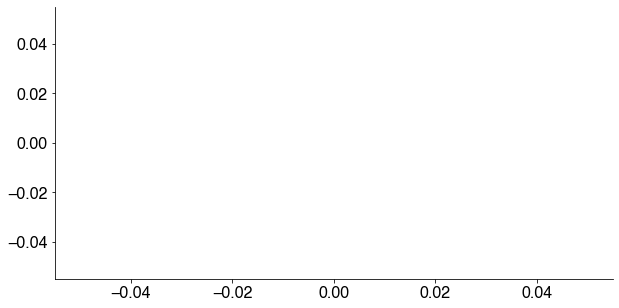

In [413]:
fig, ax = plt.subplots()
ax.plot(green_fp_ts-np.min(green_fp_ts),green_fp,'g')

In [414]:
np.min(green_fp_ts)

nan

In [416]:
np.isnan(green_fp_ts)

array([False, False, False, ..., False, False,  True])

# Current Issues with RR

- [x] Some of the SHARP timestamps are not getting activated, specifically Entry on R4, maybe others. UPDATE: fixed by redoing ROIs and thresholds. still might not be perfect though, particularly in regards to noisiness, i.e. stuttered triggering when sitting partially in ROI.
- [x] 0 offer tone and reward ommission are both triggering at the same time. Looks like the reward-omission is getting timestamped when the no-reward tone first starts (it occurs before Accept TS). __The reward omission refers to a reward omission offer tone timestamp. i.e. it is the same as the 0% offer. It is NOT the tone you hear after the countdown stops.__
- [ ] Plot cumulative food taken over time. Might be interesting to see if there is some change in strategy over the course of a trial.
- [ ] Plot FP trace before 
- [ ] Figure out way to timestamp food omission. Or estimate as 5s after "accept" timestamp?